# Module 08: Model Explainability

## Overview

Artificial Intelligence models are often considered "black boxes" because they can make accurate predictions without clearly explaining the reasons behind those predictions.

Model Explainability aims to improve transparency by identifying which input features have the greatest influence on model predictions.

In this notebook, feature importance scores obtained from the trained Random Forest models are analyzed to explain:

- Delivery Prediction Model
- Customer Satisfaction Prediction Model

The explainability results help business managers understand the major factors influencing operational performance and customer experience.

## Learning Objectives

After completing this notebook, you should be able to:

- Understand why model explainability is important.
- Interpret Random Forest feature importance.
- Visualize the most influential variables.
- Translate technical model outputs into business insights.

In [9]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

## Load Explainability Results

The feature importance scores were generated during the model training process in:

- Module 05 – Delivery Prediction
- Module 06 – Customer Satisfaction

Instead of recomputing the importance scores, this notebook loads the saved results for visualization and interpretation.

In [10]:
# ==========================================================
# Load Feature Importance Results
# ==========================================================

delivery_importance = pd.read_csv(
    "delivery_feature_importance.csv"
)

satisfaction_importance = pd.read_csv(
    "customer_satisfaction_feature_importance.csv"
)

print("Delivery Dataset Shape:", delivery_importance.shape)

print("Customer Satisfaction Shape:",
      satisfaction_importance.shape)

Delivery Dataset Shape: (134, 2)
Customer Satisfaction Shape: (139, 2)


## Delivery Prediction Model

Random Forest estimates the contribution of every feature during the training process.

Features with larger importance values contribute more towards predicting whether an order will be delivered late.

Understanding these features enables logistics managers to improve delivery performance.

In [11]:
delivery_importance.head(10)

,Feature,Importance
0,shipping_days,0.115136
1,payment_value,0.100844
2,freight_value,0.093281
3,price,0.086942
4,product_description_lenght,0.080796
5,product_volume_cm3,0.074396
6,product_weight_g,0.072770
7,product_name_lenght,0.065126
8,payment_installments,0.053587
9,product_photos_qty,0.031946


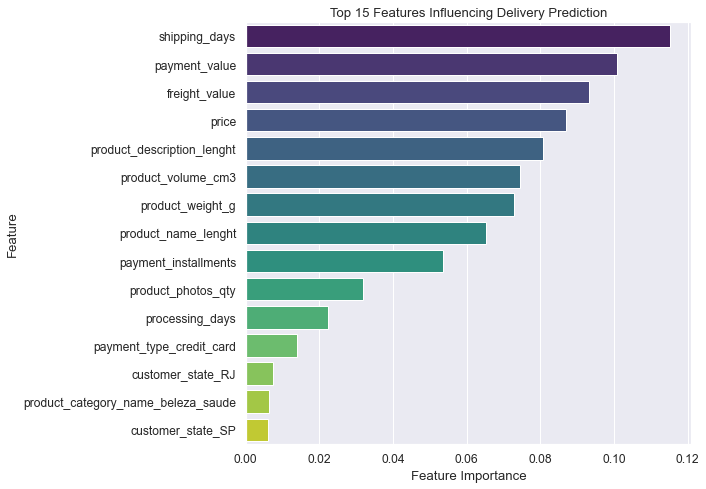

In [12]:
# Top 15 Most Important Features

delivery_top = delivery_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(

    data=delivery_top,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Features Influencing Delivery Prediction")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(

    "delivery_feature_importance.png",

    dpi=300

)

plt.show()

### Interpretation

The figure shows the variables that contributed most to predicting late deliveries.

Higher feature importance indicates a stronger influence on the model's decision.

Business managers should prioritize improving the operational processes associated with these features.

In [13]:
delivery_top.head(10)

,Feature,Importance
0,shipping_days,0.115136
1,payment_value,0.100844
2,freight_value,0.093281
3,price,0.086942
4,product_description_lenght,0.080796
5,product_volume_cm3,0.074396
6,product_weight_g,0.072770
7,product_name_lenght,0.065126
8,payment_installments,0.053587
9,product_photos_qty,0.031946


## Customer Satisfaction Model

Customer satisfaction is predicted using a Random Forest classifier.

The feature importance values indicate which variables contribute most to predicting customer satisfaction.

These insights can be used to improve customer experience and retention.

In [14]:
satisfaction_importance.head(10)

,Feature,Importance
0,delivery_delay_days,0.123668
1,delivery_days,0.089905
2,payment_value,0.072811
3,distance_km,0.070552
4,freight_value,0.061131
5,price,0.059773
6,product_description_lenght,0.051758
7,product_weight_g,0.046588
8,shipping_days,0.043421
9,product_name_lenght,0.043202


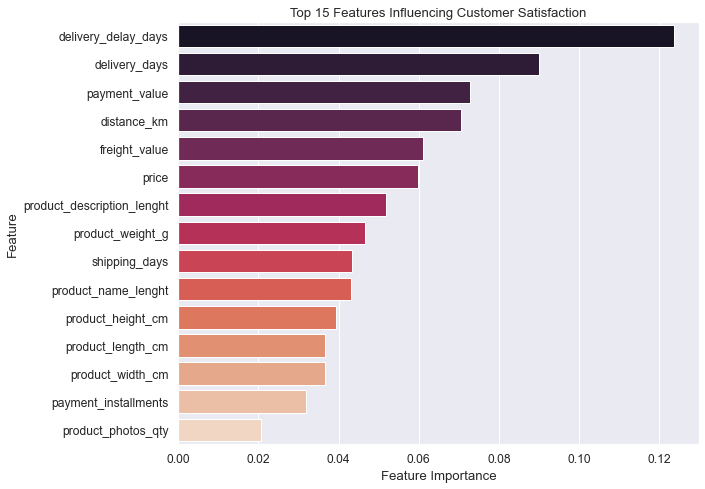

In [15]:
satisfaction_top = satisfaction_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(

    data=satisfaction_top,

    x="Importance",

    y="Feature",

    palette="rocket"

)

plt.title("Top 15 Features Influencing Customer Satisfaction")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(

    "customer_satisfaction_feature_importance.png",

    dpi=300

)

plt.show()

### Interpretation

The most important variables have the greatest impact on predicting customer satisfaction.

Managers can focus on these variables to improve customer experience and increase positive reviews.

In [16]:
satisfaction_top.head(10)

,Feature,Importance
0,delivery_delay_days,0.123668
1,delivery_days,0.089905
2,payment_value,0.072811
3,distance_km,0.070552
4,freight_value,0.061131
5,price,0.059773
6,product_description_lenght,0.051758
7,product_weight_g,0.046588
8,shipping_days,0.043421
9,product_name_lenght,0.043202


# Executive Summary

The following table summarizes the most influential feature identified for each predictive model.

In [17]:
summary = pd.DataFrame({

    "Model":[

        "Delivery Prediction",

        "Customer Satisfaction"

    ],

    "Most Important Feature":[

        delivery_top.iloc[0]["Feature"],

        satisfaction_top.iloc[0]["Feature"]

    ],

    "Importance Score":[

        delivery_top.iloc[0]["Importance"],

        satisfaction_top.iloc[0]["Importance"]

    ]

})

summary

,Model,Most Important Feature,Importance Score
0,Delivery Prediction,shipping_days,0.115136
1,Customer Satisfaction,delivery_delay_days,0.123668


# Save Explainability Results

The explainability outputs are saved for use in the Streamlit dashboard.

In [18]:
os.makedirs("../data", exist_ok=True)

summary.to_csv(

    "model_explainability_summary.csv",

    index=False

)

print("Summary saved successfully.")

Summary saved successfully.


# Business Insights

## Delivery Prediction

The model indicates that operational variables contribute most to predicting late deliveries.

Recommendations include:

- Reduce warehouse processing time.
- Improve courier efficiency.
- Monitor freight costs.
- Optimize shipping routes.
- Improve inventory management.

---

## Customer Satisfaction

Customer satisfaction is strongly influenced by delivery performance and product-related characteristics.

Recommendations include:

- Deliver products on time.
- Reduce unnecessary freight charges.
- Improve product quality.
- Enhance customer service.
- Improve communication throughout the delivery process.

# Conclusion

This notebook demonstrated how feature importance can be used to explain machine learning models.

Unlike black-box predictions, explainability provides transparency into the factors influencing model decisions.

These insights help business managers make informed operational decisions while increasing confidence in AI-based systems.

The generated explainability outputs will be integrated into the NovaMart AI Retail Intelligence Dashboard to support decision-making.